In [1]:
# import data dari kaggle
# kita pilih loan data
import kagglehub
path = kagglehub.dataset_download("zhijinzhai/loandata")

100%|██████████| 5.48k/5.48k [00:00<00:00, 5.23MB/s]

Extracting files...


In [5]:
# baca data hasil import, perhatikan kolom yang tersedia
# di titik ini bisa copy nama kolom beserta samplenya untuk tanya di AI terpisah alternatif data analytics yang bisa dilakukan
import pandas as pd
import os

# List the contents of the downloaded path to find the actual file name
files_in_path = os.listdir(path)
print(f"Files in the directory: {files_in_path}")

csv_files = [f for f in files_in_path if f.endswith('.csv')]

if csv_files:
    # Assuming the first CSV file found is the one we want to load
    file_name = csv_files[0]
    file_path = os.path.join(path, file_name)

    print(f"Attempting to load: {file_path}")
    # Load the data into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Display the first 5 rows of the DataFrame
    display(df.head())
else:
    print("No CSV files found in the downloaded directory.")
    print("Please check the directory contents and specify the correct file name if it's not a CSV or is in a subdirectory.")

Files in the directory: ['Loan payments data.csv']
Attempting to load: /root/.cache/kagglehub/datasets/zhijinzhai/loandata/versions/1/Loan payments data.csv


,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female


In [6]:
# setelah memilih satu dari lima alternatif data analytics, berit tahu AI di samping tujuan tersebut
# lalu minta dia lakukan EDA terlebih dahulu
# Display basic information about the DataFrame (data types, non-null values)
df.info()

# di sini kita cek tipe data per kolom dan jumlah baris (500)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Loan_ID         500 non-null    object 
 1   loan_status     500 non-null    object 
 2   Principal       500 non-null    int64  
 3   terms           500 non-null    int64  
 4   effective_date  500 non-null    object 
 5   due_date        500 non-null    object 
 6   paid_off_time   400 non-null    object 
 7   past_due_days   200 non-null    float64
 8   age             500 non-null    int64  
 9   education       500 non-null    object 
 10  Gender          500 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 43.1+ KB


In [19]:
# Display descriptive statistics for numerical columns
# Dia cek stat buat numerical column yang ternyata termasuk kolom yang seharusnya berbentuk tanggal
display(df.describe())

,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,is_default
count,500.000000,500.000000,500,500,400,500.000000,500.000000,500.000000
mean,943.200000,22.824000,2016-09-11 09:50:24.000000256,2016-10-05 08:18:14.400000256,2016-10-05 20:51:58.349999872,14.404000,31.116000,0.400000
min,300.000000,7.000000,2016-09-08 00:00:00,2016-09-15 00:00:00,2016-09-09 13:45:00,0.000000,18.000000,0.000000
25%,1000.000000,15.000000,2016-09-11 00:00:00,2016-09-25 00:00:00,2016-09-25 11:57:15,0.000000,27.000000,0.000000
50%,1000.000000,30.000000,2016-09-11 00:00:00,2016-10-10 00:00:00,2016-10-05 21:19:00,0.000000,30.000000,0.000000
75%,1000.000000,30.000000,2016-09-12 00:00:00,2016-10-11 00:00:00,2016-10-11 16:00:00,12.000000,35.000000,1.000000
max,1000.000000,30.000000,2016-09-14 00:00:00,2016-11-12 00:00:00,2016-12-02 09:45:00,76.000000,51.000000,1.000000
std,115.240274,8.000064,NaN,NaN,NaN,25.614312,6.084784,0.490389


In [8]:
# Convert date columns to datetime objects
# sehingga di sini dia perlu ubah tiga kolom yang seharusnya tipenya tanggal
date_cols = ['effective_date', 'due_date', 'paid_off_time']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# di atas tadi AI juga menemukan kolom past_due_days banyak NaN, di sini dia memilih mengganti NaN dengan 0
# Fill missing values in 'past_due_days' with 0, assuming NaN means not past due
df['past_due_days'] = df['past_due_days'].fillna(0)

# Display info again to confirm changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Loan_ID         500 non-null    object        
 1   loan_status     500 non-null    object        
 2   Principal       500 non-null    int64         
 3   terms           500 non-null    int64         
 4   effective_date  500 non-null    datetime64[ns]
 5   due_date        500 non-null    datetime64[ns]
 6   paid_off_time   400 non-null    datetime64[ns]
 7   past_due_days   500 non-null    float64       
 8   age             500 non-null    int64         
 9   education       500 non-null    object        
 10  Gender          500 non-null    object        
dtypes: datetime64[ns](3), float64(1), int64(3), object(4)
memory usage: 43.1+ KB


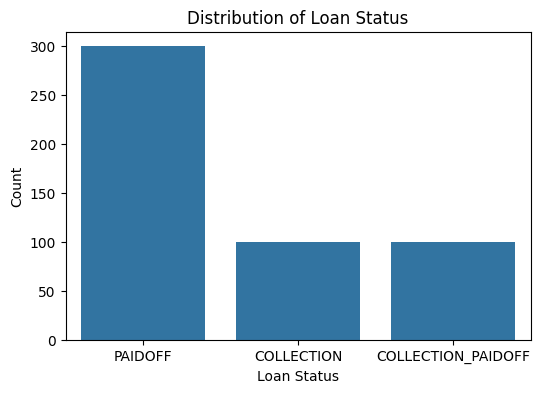

loan_status
PAIDOFF               300
COLLECTION            100
COLLECTION_PAIDOFF    100
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# di sini dia melihat distribusi kolom loan_status, hasilnya 100 yg terbayar sebelum ditagih, 100 yg posisi masih ditagih, dan 100 yang lunas setelah ditagih
# Analyze the distribution of the target variable: loan_status
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

print(df['loan_status'].value_counts())

Borrower Age and Default Status:
Average Age for PAIDOFF loans: ~31.21 years
Average Age for DEFAULT loans: ~30.975 years
Insight: Age appears to be a weak predictor of default, as the average ages and distributions for both groups are very similar.

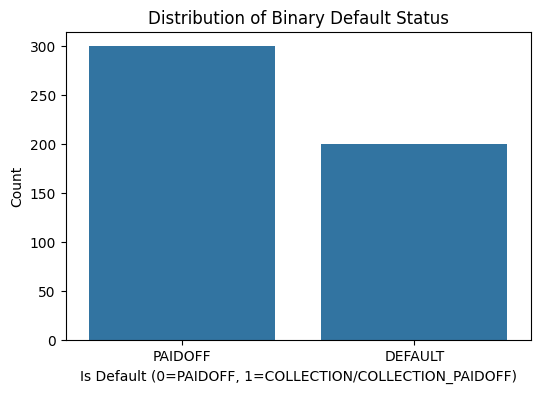

is_default
0    300
1    200
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# di sini dia membuat binary padahal kolom aslinya punya 3 nilai, dia kelompokkan menjadi dua saja.
# dia membuat kolom baru untuk menampung hasil klasifikasi binary 'is_default'
# Map 'loan_status' to a binary target variable: 0 for PAIDOFF, 1 for default
df['is_default'] = df['loan_status'].apply(lambda x: 0 if x == 'PAIDOFF' else 1)

# Display the distribution of the new binary target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='is_default', data=df)
plt.title('Distribution of Binary Default Status')
plt.xlabel('Is Default (0=PAIDOFF, 1=COLLECTION/COLLECTION_PAIDOFF)')
plt.ylabel('Count')
plt.xticks([0, 1], ['PAIDOFF', 'DEFAULT'])
plt.show()

print(df['is_default'].value_counts())

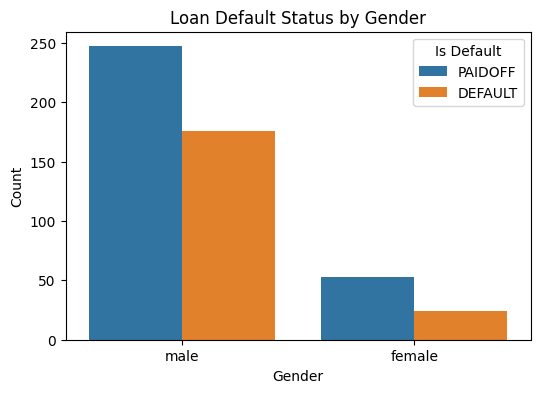

is_default         0         1
Gender                        
female      0.688312  0.311688
male        0.583924  0.416076


In [13]:
# dia mulai melihat relasi antara beberapa kolom calon variabel dengan kolom target
# Analyze the relationship between 'Gender' and 'is_default'
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='is_default', data=df)
plt.title('Loan Default Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Is Default', labels=['PAIDOFF', 'DEFAULT'])
plt.show()

# Show percentage of default by gender
print(df.groupby('Gender')['is_default'].value_counts(normalize=True).unstack())

Gender and Loan Default:
Female borrowers: Approximately 31.17% default rate.
Male borrowers: Approximately 41.61% default rate.
Insight: Male borrowers show a higher propensity to default than female borrowers in this dataset.

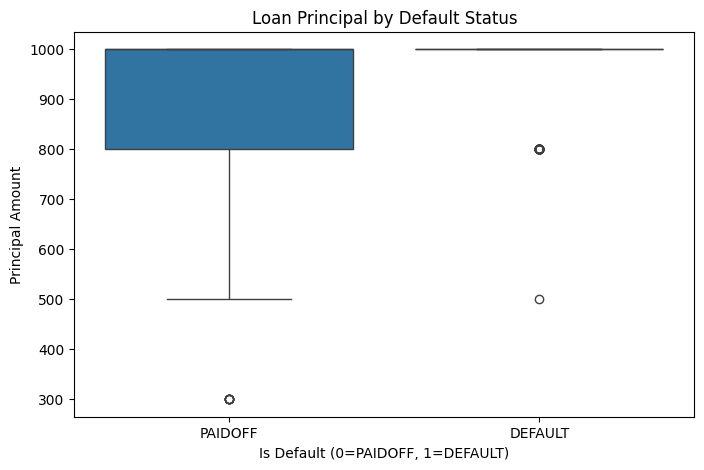

is_default
0    935.0
1    955.5
Name: Principal, dtype: float64


In [14]:
# Analyze the relationship between 'Principal' and 'is_default'
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_default', y='Principal', data=df)
plt.title('Loan Principal by Default Status')
plt.xlabel('Is Default (0=PAIDOFF, 1=DEFAULT)')
plt.ylabel('Principal Amount')
plt.xticks([0, 1], ['PAIDOFF', 'DEFAULT'])
plt.show()

# Display mean Principal by default status
print(df.groupby('is_default')['Principal'].mean())

Principal Amount and Loan Default:
Average Principal for PAIDOFF loans: ~$935 * **Average Principal for DEFAULT loans:** ~$$935 * **Average Principal for DEFAULT loans:** ~$955.5
Insight: Loans with slightly higher principal amounts (around $955.5) show a marginally increased tendency to default compared to paid-off loans. The difference is minor, suggesting principal amount alone may not be a strong predictor.

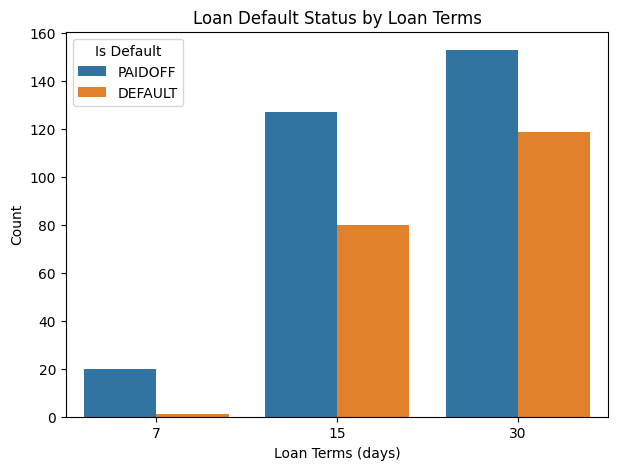

is_default         0         1
terms                         
7           0.952381  0.047619
15          0.613527  0.386473
30          0.562500  0.437500


In [17]:
# Analyze the relationship between 'terms' and 'is_default'
plt.figure(figsize=(7, 5))
sns.countplot(x='terms', hue='is_default', data=df)
plt.title('Loan Default Status by Loan Terms')
plt.xlabel('Loan Terms (days)')
plt.ylabel('Count')
plt.legend(title='Is Default', labels=['PAIDOFF', 'DEFAULT'])
plt.show()

# Show percentage of default by terms
print(df.groupby('terms')['is_default'].value_counts(normalize=True).unstack())

Loan Terms and Default Status:
7-day terms: Very low default rate (sekitar 4.76%).
15-day terms: Moderate default rate (sekitar 38.65%).
30-day terms: Highest default rate (sekitar 43.75%).
Insight: There is a clear positive correlation between increasing loan terms and the likelihood of default.

Borrower Age and Default Status:
Average Age for PAIDOFF loans: ~31.21 years
Average Age for DEFAULT loans: ~30.975 years
Insight: Age appears to be a weak predictor of default, as the average ages and distributions for both groups are very similar.

### Feature Engineering: Encoding Categorical Variables
To prepare the data for model training, we need to convert categorical variables into numerical representations. We will use one-hot encoding for `Gender` and `education`.

In [20]:
# One-hot encode 'Gender' column
df = pd.get_dummies(df, columns=['Gender'], prefix='Gender', drop_first=True)

# One-hot encode 'education' column
df = pd.get_dummies(df, columns=['education'], prefix='Education', drop_first=True)

# Display the updated DataFrame with new encoded columns
print("DataFrame after One-Hot Encoding:")
display(df.head())

DataFrame after One-Hot Encoding:


,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,is_default,Gender_male,Education_High School or Below,Education_Master or Above,Education_college
0,xqd20166231,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-09-14 19:31:00,0.0,45,0,True,True,False,False
1,xqd20168902,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-10-07 09:00:00,0.0,50,0,False,False,False,False
2,xqd20160003,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-09-25 16:58:00,0.0,33,0,False,False,False,False
3,xqd20160004,PAIDOFF,1000,15,2016-09-08,2016-09-22,2016-09-22 20:00:00,0.0,27,0,True,False,False,True
4,xqd20160005,PAIDOFF,1000,30,2016-09-09,2016-10-08,2016-09-23 21:36:00,0.0,28,0,False,False,False,True


### Dropping Unnecessary Columns
Now that we have encoded categorical variables and identified columns not suitable for direct model training, we will drop the original categorical columns and other irrelevant columns (`Loan_ID`, `loan_status`, and date columns) from the DataFrame.

### Addressing Data Leakage: Removing `past_due_days`

As discussed, the `past_due_days` feature is a strong candidate for data leakage because it directly indicates whether a loan has entered a default state. To build a more realistic and generalizable model, we must remove this feature from our dataset.

I will now redefine the `df_model` DataFrame to exclude `past_due_days` and then rerun the subsequent modeling steps.

In [30]:
# Drop 'Loan_ID', 'loan_status', 'past_due_days', and the date columns, as they are not used as direct features
# 'Gender' and 'education' columns were already removed/replaced by one-hot encoding in the previous step
df_model = df.drop(columns=['Loan_ID', 'loan_status', 'effective_date', 'due_date', 'paid_off_time', 'past_due_days'])

# Display the columns of the new DataFrame to confirm the changes
print("Columns in the DataFrame after dropping unnecessary columns (including 'past_due_days'):")
print(df_model.columns)

# Display the head of the processed DataFrame
print("\nProcessed DataFrame head:")
display(df_model.head())

Columns in the DataFrame after dropping unnecessary columns (including 'past_due_days'):
Index(['Principal', 'terms', 'age', 'is_default', 'Gender_male',
       'Education_High School or Below', 'Education_Master or Above',
       'Education_college'],
      dtype='object')

Processed DataFrame head:


,Principal,terms,age,is_default,Gender_male,Education_High School or Below,Education_Master or Above,Education_college
0,1000,30,45,0,True,True,False,False
1,1000,30,50,0,False,False,False,False
2,1000,30,33,0,False,False,False,False
3,1000,15,27,0,True,False,False,True
4,1000,30,28,0,False,False,False,True


### Data Re-Split
With `past_due_days` removed, we need to re-split our data into training and testing sets.

In [31]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_model.drop(columns=['is_default'])
y = df_model['is_default']

# Split the data into training and testing sets
# We'll use a test size of 30% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of target variable in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of target variable in testing set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (350, 7)
Shape of X_test: (150, 7)
Shape of y_train: (350,)
Shape of y_test: (150,)

Distribution of target variable in training set:
is_default
0    0.6
1    0.4
Name: proportion, dtype: float64

Distribution of target variable in testing set:
is_default
0    0.6
1    0.4
Name: proportion, dtype: float64


### Model Retraining
Now, let's retrain the Logistic Regression model with the updated feature set.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model retrained successfully without 'past_due_days'.")

Logistic Regression model retrained successfully without 'past_due_days'.


### Model Re-evaluation
Let's re-evaluate the model's performance on the test set.

In [33]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.5933333333333334

Confusion Matrix:
 [[88  2]
 [59  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.98      0.74        90
           1       0.33      0.02      0.03        60

    accuracy                           0.59       150
   macro avg       0.47      0.50      0.39       150
weighted avg       0.49      0.59      0.46       150



### Feature Importance Re-analysis
Let's examine the feature importance again with the new model.

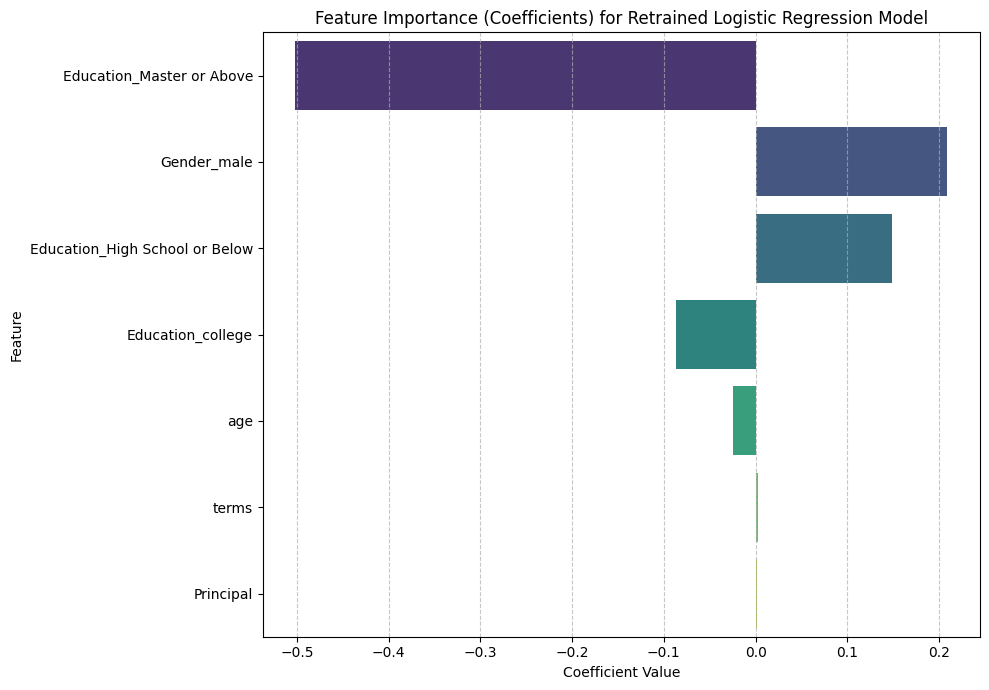

,Feature,Coefficient
0,Education_Master or Above,-0.501685
1,Gender_male,0.209057
2,Education_High School or Below,0.148861
3,Education_college,-0.086656
4,age,-0.024520
5,terms,0.003026
6,Principal,0.001085


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature names from X_train
feature_names = X_train.columns

# Get the coefficients from the trained model
# For binary classification, coef_ is typically a 2D array, we take the first (and only) row
coefficients = log_reg_model.coef_[0]

# Create a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the features by the absolute value of their coefficients for better visualization
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

# Plotting feature importance
plt.figure(figsize=(10, 7))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Coefficients) for Retrained Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(feature_importance[['Feature', 'Coefficient']].reset_index(drop=True))

### ROC Curve and AUC Score Re-evaluation
Finally, let's check the ROC curve and AUC score for the retrained model.

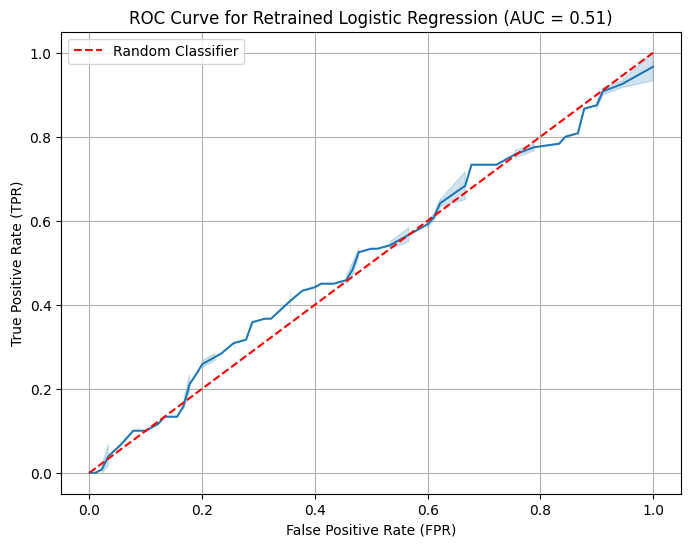

The AUC score for the Retrained Logistic Regression model is: 0.5106


In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Get the predicted probabilities for the positive class (is_default=1)
# predict_proba returns probabilities for [class 0, class 1]
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier') # Diagonal dashed line
plt.title(f'ROC Curve for Retrained Logistic Regression (AUC = {auc_score:.2f})')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.grid(True)
plt.legend()
plt.show()

print(f"The AUC score for the Retrained Logistic Regression model is: {auc_score:.4f}")

### Save the Trained Model and Feature Names

Before creating the Streamlit application, we need to save the trained `log_reg_model` and the `X.columns` (feature names) so that the Streamlit app can load them. We'll use `joblib` for this, as it's efficient for scikit-learn models.

In [36]:
import joblib

# Save the model
joblib.dump(log_reg_model, 'logistic_regression_model.pkl')

# Save the feature names (columns X was trained on)
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Model and feature names saved successfully!")

Model and feature names saved successfully!
